# Solve Master Equation, get distribution and compare analytic/numerical statistics summaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import imageio.v2 as imageio
from matplotlib.ticker import FuncFormatter
import os

# Parameters
lambda_ = 0.05  # proliferation rate
mu = 0.02  # death rate
N = 450  # max cell count

A: np.ndarray = np.zeros((N + 1, N + 1))
for n in range(N + 1):
    if n > 0:
        A[n, n - 1] = lambda_ * (n - 1)
    if n < N:
        A[n, n + 1] = mu * (n + 1)
    A[n, n] = -(lambda_ + mu) * n


def master_eq(t, P):
    return A @ P


P0: np.ndarray = np.zeros(N + 1)
P0[5] = 1.0

t_span: tuple[int, int] = (0, 96)
t_eval: np.ndarray = np.linspace(*t_span, 97)
sol = solve_ivp(master_eq, t_span, P0, t_eval=t_eval)

os.makedirs("frames", exist_ok=True)
filenames: list[str] = []

for i in range(len(t_eval)):
    fig, ax = plt.subplots(figsize=(12, 6))
    x_vals: np.ndarray = np.arange(N + 1)
    y_vals = sol.y[:, i]

    bin_size = 10
    x_binned: np.ndarray = np.arange(0, N + 1, bin_size)
    y_binned: np.ndarray = np.array([y_vals[i : i + bin_size].sum() for i in x_binned])
    mask = y_binned > 0
    x_binned = x_binned[mask]
    y_binned = y_binned[mask]
    x_centers = x_binned + bin_size / 2

    ax.bar(x_centers, y_binned, width=bin_size * 0.6, color="skyblue", edgecolor="blue", linewidth=0.8)
    ax.plot(x_centers, y_binned + np.max(y_binned) * 0.01, color="black", linewidth=1.2, label="Binned Probability Curve")

    ax.set_title(f"Tumor Cell Distribution at t = {int(t_eval[i])}", fontsize=14)
    ax.set_xlabel("Number of Tumor Cells (n)", fontsize=12)
    ax.set_ylabel("Probability Having\nn Tumor Cells at Time t", fontsize=12, rotation=0, labelpad=80)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.4f}"))

    y_max = max(y_binned)
    ax.set_ylim(0, y_max * 1.1 if y_max > 0 else 1e-3)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    fig.subplots_adjust(left=0.3)

    fname: str = f"frames/frame_{i:03d}.png"
    plt.savefig(fname)
    plt.close()
    filenames.append(fname)

with imageio.get_writer("picture/tumor_distribution.gif", mode="I", duration=0.1) as writer:
    for fname in filenames:
        image = imageio.imread(fname)
        writer.append_data(image)  # pyright: ignore[reportAttributeAccessIssue]

for fname in filenames:
    os.remove(fname)
os.removedirs("frames")

## Example Output

![](picture/tumor_distribution.gif)

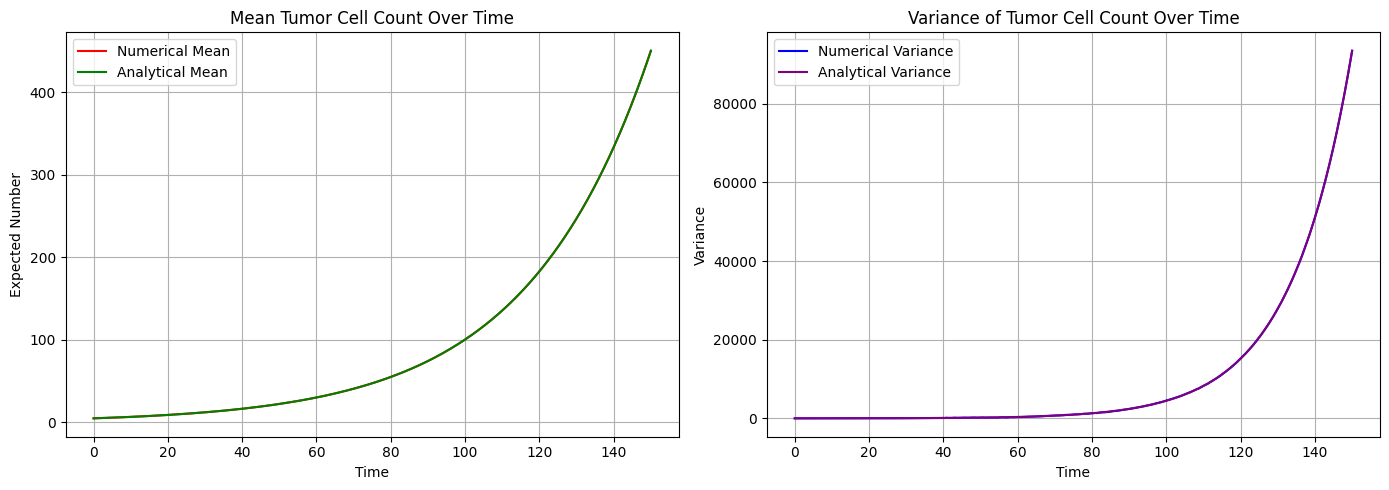

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
lambda_ = 0.05  # proliferation rate
mu = 0.02  # death rate
N = 3000

# Step 1: Create the transition matrix A
A = np.zeros((N + 1, N + 1))
for n in range(N + 1):
    if n > 0:
        A[n, n - 1] = lambda_ * (n - 1)
    if n < N:
        A[n, n + 1] = mu * (n + 1)
    A[n, n] = -(lambda_ + mu) * n


# Step 2: Define ODE system
def master_eq(t, P):
    return A @ P


# Step 3: Initial condition
P0 = np.zeros(N + 1)
n0 = 5
P0[n0] = 1.0

# Step 4: Solve system
t_span = (0, 150)
t_eval = np.linspace(*t_span, 601)
sol = solve_ivp(master_eq, t_span, P0, t_eval=t_eval)

# Step 5: Compute numerical moments
states = np.arange(N + 1)
mean_n = np.dot(states, sol.y)
second_moment = np.dot(states**2, sol.y)
variance_n = second_moment - mean_n**2

# Step 6: Analytical moments
growth = np.exp((lambda_ - mu) * t_eval)
expected_analytical = n0 * growth
variance_analytical = n0 * (lambda_ + mu) / (lambda_ - mu) * (growth - 1) * growth

# Step 7: Plot 1x2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean
axes[0].plot(t_eval, mean_n, label="Numerical Mean", color="red")
axes[0].plot(t_eval, expected_analytical, label="Analytical Mean", color="green")
axes[0].set_title("Mean Tumor Cell Count Over Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Expected Number")
axes[0].legend()
axes[0].grid(True)

# Variance
axes[1].plot(t_eval, variance_n, label="Numerical Variance", color="blue")
axes[1].plot(t_eval, variance_analytical, label="Analytical Variance", color="purple")
axes[1].set_title("Variance of Tumor Cell Count Over Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Variance")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()